# Oppgave 2: Forsikringskrav

Vi lar $X(t)$ betegne antall forsikringskrav et selskap mottar i løpet av intervallet $[0, t]$. Vi antar at ${X(t) : t \geq 0}$ kan modelleres som en poisson-prosess, der t er antall dager fra 1. januar kl. 00:00:00. La raten være $\lambda (t) = 1.5, t \geq 0$.

Nødvendige biblioteker:

In [21]:
import numpy as np
from matplotlib import pyplot as plt

## Oppgave 2a:

* Vi vil finne sannsynligheten for at det har kommet inn fler enn 100 krav 1. mars 00:00:00 (59 dager).
    $P(X(59) > 100) = 1 - P(X(59) <= 100) = 1 - e^{-1.5 \cdot 59} \sum_{i=0}^{100} \frac{(1.5 \cdot 59)^i}{i!} = 0.1028$
    Sannsynligheten er altså rundt 10,3%.


* Vi verifiserer ved å simulere 100 realisasjoner av denne Poisson-prosessen

In [22]:
lam = 1.5
t = 59
size = 1000

events = np.random.poisson(lam = lam*t, size = size)

print(f"Andel av realisasjonene med mer enn 100 hendelser: {np.sum(events > 100)/size}")


Andel av realisasjonene med mer enn 100 hendelser: 0.112


* Vi ser at simularingen stemmer godt med den teoretiske verdien, selv om usikkerheten fremdeles er vel forbi én desimal for bare 1000 realisasjoner. 

* Vi lager så en figur som viser 10 realisasjoner av $X(t), 0 \leq t \leq 59$. For å gjøre det bruker vi at oppholdstidene (sojourn times) er uavhengig eksponensialfordelte. Vi genererer 10 serier med nok ventetider til at vi trygt kommer over 59 dager.

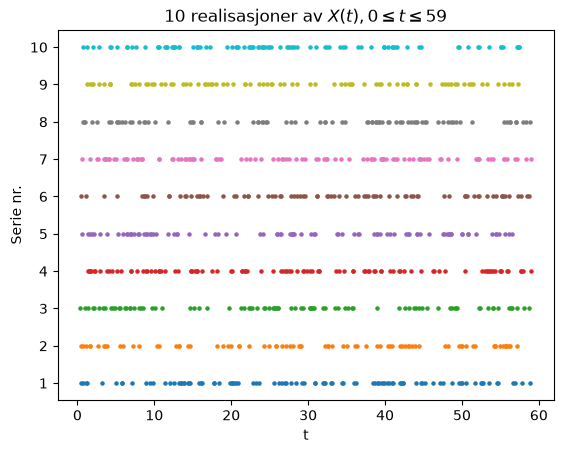

In [30]:
fig, ax = plt.subplots()
for i in range(1, 11):
    # A size of lam*2*t gives an expected total of twice the size of t.
    sojourn_times = np.random.exponential(scale = 1/lam, size = int(lam*2*t))
    event_times = np.cumsum(sojourn_times)
    event_times = event_times[event_times <= 59]

    ax.scatter(event_times, [i]*len(event_times), s = 5)

ax.set_yticks([i for i in range(1, 11)])
ax.set(title = r"10 realisasjoner av $X(t), 0 \leq t \leq 59$", xlabel = "t", ylabel = "Serie nr.")

plt.show()

## Oppgave 2b:

Vi antar i det videre at beløpskravene er uavhengige, og uavhengige av tidspunktet de kommer på. Vi antar at kravene (i mill. kr) er eksponensialfordelte med rate $\gamma = 10$. Betegn krav $i$ ved $C_i \sim Exp(\gamma), i = 1, 2,...$. La videre det totale beløpskravet ved tid t være gitt ved $Z(t) = \sum_{i = 1}^{X(t)} C_i$

* Vi simulerer prosessen 1000 ganger forå estimere sannsynligheten for at det totale beløpskravet overstiger 8 millioner kroner 1. mars 00:00:00 (59 dager).

In [41]:
nsims = 1000

lam = 1.5
t = 59
size = 1000
gamma = 10

events = np.random.poisson(lam = lam*t, size = size)
amounts = np.random.exponential(scale = 1/gamma, size = np.sum(events))

start_indexes = np.zeros(size, dtype = int)
start_indexes[1:] = np.cumsum(events[:-1])

total_amounts = np.add.reduceat(amounts, start_indexes)

print(f"Andel av realisasjonene der totalkravet er under 8 mill: {np.sum(total_amounts < 8)/size}")


Andel av realisasjonene der totalkravet er under 8 mill: 0.265


* Vi lager så en figur som viser 10 realisasjoner av $Z(t)$.

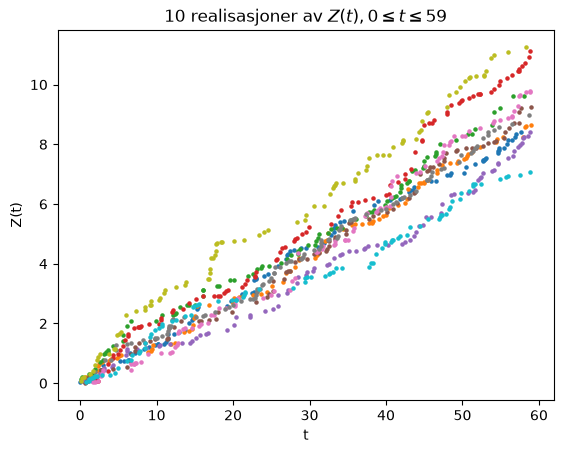

In [44]:
fig, ax = plt.subplots()
for i in range(1, 11):
    # A size of lam*2*t gives an expected total of twice the size of t.
    sojourn_times = np.random.exponential(scale = 1/lam, size = int(lam*2*t))
    event_times = np.cumsum(sojourn_times)
    event_times = event_times[event_times <= 59]
    claims = np.random.exponential(scale = 1/gamma, size = len(event_times))
    total_claim = np.cumsum(claims)

    ax.scatter(event_times, total_claim, s = 5)

ax.set(title = r"10 realisasjoner av $Z(t), 0 \leq t \leq 59$", xlabel = "t", ylabel = "Z(t)")

plt.show()

## Oppgave 2c:

Vi undersøker kun krav som overstiger 250 000 kr. La $Y(t)$ være antall krav mottatt i intervallet $[0, t]$ som må undersøkes. Vi ønsker å vise at $\{Y(t) : t \geq 0\}$ er en poisson-prosess og avgjøre raten.

La $C_i \sim Exp(\gamma)$ være beløpskrav $i$. Vi antar at vi kan modellere $\{X(t), t \geq 0 \}$ som en poissonprosess med rate $\lambda(t) = 1.5, t \geq 0$.

Vi har at $P(C_i > 0.25) = 1 - P(C_i \leq 0.25) = 1 - (1 - e^{-0.25\gamma}) = e^{-0.25\gamma}$. Dermed har vi at hver hendelse i prosessen $\{X(t), t \geq 0 \}$ har en sannsynlighet $p = e^{-0.25\gamma}$ for å være en hendelse i $\{Y(t), t \geq 0 \}$. Siden alle $C_i$ er uavhengige er også disse sannsynlighetene det. Dermed har vi

$A(n) = \sum_{i = 1}^k I(C_i > 0.25) \sim Binom(n, p)$

Fra før av har vi $P(X(t) = n) = \frac{(\lambda t)^n e^{-\lambda t}}{n!}$.

Vi har da ved loven om total sannsynlighet:

$P(Y(t) = k) =  \sum_{n = k}^{\inf} P(Y(t) = k \vert X(t) = n ) = \sum_{n = k}^{\inf} P(A(n) = k) \cdot P(X(t) = n)$

Vi setter inn for uttrykkene:

$= \sum_{n = k}^{\inf} \binom{n}{k} p^k (1 - p)^{n - k} \cdot \frac{(\lambda t)^n e^{-\lambda t}}{n!} = \sum_{n = k}^{\inf} \frac{n!}{k!(n-k)!} p^k (1 - p)^{n - k} \cdot \frac{(\lambda t)^n e^{-\lambda t}}{n!}$

Vi forkorter $n!$, trekker ut konstanter fra summen og endrer indeksen fra $n = k$ til $n = 0$.

$ = \frac{p^k}{k!} e^{-\lambda t} \sum_{n = k}^{\inf} \frac{(1 - p)^{n - k} }{(n-k)!} \cdot (\lambda t)^n = \frac{p^k}{k!} e^{-\lambda t} \sum_{n = 0}^{\inf} \frac{(1 - p)^{n} }{n!} \cdot (\lambda t)^{n+k} = \frac{p^k (\lambda t)^{k}}{k!} e^{-\lambda t} \sum_{n = 0}^{\inf} \frac{(1 - p)^{n} }{n!} \cdot (\lambda t)^{n} = \frac{(p \lambda t)^{k}}{k!} e^{-\lambda t} \sum_{n = 0}^{\inf} \frac{((1 - p)\lambda t)^n }{n!}$

Vi kjenner igjen summen som rekken til $e^{(1 - p)\lambda t}$

$ = \frac{(p \lambda t)^{k}}{k!} e^{(1 - p)\lambda t-\lambda t} = \frac{(p\lambda t)^{k}}{k!} e^{-p\lambda t}$

Vi får dermed

$P(Y(t) = k) = \frac{(p\lambda t)^{k}}{k!} e^{-p\lambda t}$

Så $Y(t)$ er poissonfordelt med parameter $p \lambda = e^{-0.25\gamma} \lambda = 1.5 \cdot e^{-2.5} = 0.123$

Dermed er $\{Y(t), t \geq 0 \}$ en poissonprosess.